# Hegaxons

Build h3 hex grid 

Build H3 resolution-9 hexagon grid for the GWR analysis.

Pipeline: 
1. Load dissolved study boundary (Inverclyde + 10 km Argyll & Bute buffer)
2. Reproject to WGS84 (EPSG:4326), because H3 operates in lat/lon
3. Enumerate H3 res-9 cells covering the boundary, with buffered edge recovery
   to retain partial boundary hexes
4. Materialise each cell as a shapely polygon (WGS84)
5. Reproject the hex layer to EPSG:3035 for area-based analysis
6. Filter to hexes intersecting the study boundary
7. Filter to hexes with land fraction >= 0.50
8. Add a stable h3_id primary key and area attributes
9. Save as GeoPackage for downstream joins

Chapter 3 alignment: 
- Resolution 9: average edge length ~174 m; average cell area ~0.105 km²
- Analysis CRS: EPSG:3035 for area-preserving statistics
- Land-fraction filter: reduces Firth of Clyde water cells contaminating denominators

In [1]:
from pathlib import Path
import warnings
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union


BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")

STUDY_BOUNDARY = BASE / "study_area_10Kmbuffer_dissolved.shp"


LAND_MASK = BASE / "DATA/HRL_imperviousness/Results/IMD_2018_010m_eu_03035_v020/DATA/bdline_gpkg_gb/Data/bdline_gb.gpkg"
LAND_MASK_LAYER = "country_region"

OUT_HEX = BASE / "hex_h3_res9.gpkg"

H3_RES = 9
TARGET_CRS = "EPSG:3035"
WGS84 = "EPSG:4326"
LAND_MIN_FRAC = 0.50

#  H3 compatibiklity shim (v3 <-> v4)
# h3-py v4 dropped the 'h3_' prefix from most functions and renamed a few.
# The shim below binds a single set of names regardless of which version is
# installed, so the rest of the script doesn't have to know.
import h3

if hasattr(h3, "polygon_to_cells"):
    # v4 API
    _polygon_to_cells = h3.polygon_to_cells
    _cell_to_boundary = h3.cell_to_boundary
    def _h3_shape(coords_lat_lng, holes=None):
        # v4 uses h3.LatLngPoly (list of (lat, lng) tuples).
        return h3.LatLngPoly(coords_lat_lng, *(holes or []))
    H3_MAJOR = 4
elif hasattr(h3, "polyfill"):
    # v3 API
    def _polygon_to_cells(shape, res):
        return h3.polyfill(shape, res, geo_json_conformant=False)
    def _cell_to_boundary(h):
        # v3 returns (lat, lng); ensure same order as v4.
        return h3.h3_to_geo_boundary(h, geo_json=False)
    def _h3_shape(coords_lat_lng, holes=None):
        # v3 expects a GeoJSON-like dict.
        return {
            "type": "Polygon",
            "coordinates": [[(lng, lat) for (lat, lng) in coords_lat_lng]]
                           + [[(lng, lat) for (lat, lng) in h] for h in (holes or [])],
        }
    H3_MAJOR = 3
else:
    raise ImportError("h3-py not found or unrecognised version.")

print(f"Using h3-py major version: {H3_MAJOR}")


# Load boundary, reporject to WGS84
print(f"Loading study boundary: {STUDY_BOUNDARY}")
boundary = gpd.read_file(STUDY_BOUNDARY)
print(f"  source CRS: {boundary.crs}")

# Dissolve to a single (multi)polygon just in case the input has multiple
# features. The dissolved outline is what H3 will fill.
boundary_geom_native = unary_union(boundary.geometry.values)
boundary_wgs = gpd.GeoSeries([boundary_geom_native],
                             crs=boundary.crs).to_crs(WGS84).iloc[0]
print(f"  reprojected to WGS84 for H3")


# Enumerate H3 cells intersecting the boundary 
# H3's polygon-fill returns cells whose *centroid* falls inside the polygon.For an AOI-boundary application we want any cell that intersects the
# boundary at all, otherwise we lose a partial-hex ring around the edge.Standard trick: fill each constituent polygon, plus fill a small outward
# buffer, then take the union.
def cells_for_polygon(poly):
    """Return an H3 cell id set covering the given shapely polygon."""
    if poly.is_empty:
        return set()
    # H3 needs coords as (lat, lng), shapely gives (x=lng, y=lat).
    exterior = [(y, x) for x, y in poly.exterior.coords]
    holes = [[(y, x) for x, y in ring.coords] for ring in poly.interiors]
    shape = _h3_shape(exterior, holes)
    return set(_polygon_to_cells(shape, H3_RES))


# Handle Polygon vs MultiPolygon uniformly.
if boundary_wgs.geom_type == "MultiPolygon":
    polys = list(boundary_wgs.geoms)
else:
    polys = [boundary_wgs]

cells = set()
for p in polys:
    cells |= cells_for_polygon(p)

# Edge-ring recovery: Buffer the boundary slightly (in metres, so switch to the equal-area CRS first, buffer, switch back), fill, and union with the
# initial set. I want to make sure partially-overlapping hexes on the boundary are captured.
buffered_m = (gpd.GeoSeries([boundary_geom_native], crs=boundary.crs)
              .to_crs(TARGET_CRS)
              .buffer(200)                # 200 m ~ 1 hex radius at res 9
              .to_crs(WGS84).iloc[0])
if buffered_m.geom_type == "MultiPolygon":
    for p in buffered_m.geoms:
        cells |= cells_for_polygon(p)
else:
    cells |= cells_for_polygon(buffered_m)

print(f"H3 res-{H3_RES} cells enumerated: {len(cells):,}")
if not cells:
    raise RuntimeError("H3 returned zero cells - check boundary orientation "
                       "and CRS.")


# Materialise cells as shapely polygons 
# _cell_to_boundary returns [(lat, lng), ...]. shapely wants (x=lng, y=lat).
def cell_to_polygon(h):
    coords = _cell_to_boundary(h)
    return Polygon([(lng, lat) for (lat, lng) in coords])

# Suppress a benign shapely deprecation warning about closed-ring handling that fires on some GEOS versions.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    hex_wgs = gpd.GeoDataFrame(
        {"h3_id": list(cells)},
        geometry=[cell_to_polygon(h) for h in cells],
        crs=WGS84,
    )

print(f"Hex GeoDataFrame built: {len(hex_wgs):,} rows in WGS84")


# Reproject to EPSG:3035 for area/ distance work 
hex_grid = hex_wgs.to_crs(TARGET_CRS)
print(f"Reprojected to {TARGET_CRS}")


# Clip to study boundary (removes hexes beyond the AOI edge)
boundary_3035 = (gpd.GeoSeries([boundary_geom_native], crs=boundary.crs)
                 .to_crs(TARGET_CRS).iloc[0])
before = len(hex_grid)
hex_grid = hex_grid[hex_grid.geometry.intersects(boundary_3035)].copy()
print(f"After boundary intersect filter: {len(hex_grid):,} "
      f"(-{before - len(hex_grid):,})")


# Clip to land (LAND_MIN_FRAC threshold)
# I keep the full hex geometry and just filter by land fraction to preserves the regular hex tessellation 
# (essential for queen-contiguity spatial weights later). Coastal hexes below the threshold are dropped entirely.
# Threshold: 50% by default. A hex mostly in the Firth has too little land signal to be a meaningful analysis unit.
print(f"Loading land mask: {LAND_MASK} | layer={LAND_MASK_LAYER}")
land = gpd.read_file(LAND_MASK, layer=LAND_MASK_LAYER)
print(land.geom_type.value_counts())
print(land.crs)
if land.crs != hex_grid.crs:
    land = land.to_crs(hex_grid.crs)
land_geom = unary_union(land.geometry.values)

hex_grid["hex_area_m2"] = hex_grid.geometry.area
# Intersect area with land 
hex_grid["land_area_m2"] = hex_grid.geometry.intersection(land_geom).area
hex_grid["land_frac"] = hex_grid["land_area_m2"] / hex_grid["hex_area_m2"]

before = len(hex_grid)
hex_grid = hex_grid[hex_grid["land_frac"] >= LAND_MIN_FRAC].copy()
print(f"After land-fraction >= {LAND_MIN_FRAC}: {len(hex_grid):,} "
      f"(-{before - len(hex_grid):,})")


# Finilise and save 
hex_grid = hex_grid[["h3_id", "hex_area_m2", "land_area_m2", "land_frac",
                     "geometry"]].reset_index(drop=True)

# Check all h3_ids should be unique; the grid should be a valid layer.
assert hex_grid["h3_id"].is_unique, "Duplicate H3 ids in output - bug."
assert hex_grid.geometry.is_valid.all(), "Invalid geometries present."

print("\nSummary:")
print(f"  hexes:                {len(hex_grid):,}")
print(f"  mean hex_area_m2:     {hex_grid['hex_area_m2'].mean():,.0f}")
print(f"  mean land_frac:       {hex_grid['land_frac'].mean():.3f}")
print(f"  total land area km2:  {hex_grid['land_area_m2'].sum() / 1e6:,.1f}")

hex_grid.to_file(OUT_HEX, driver="GPKG")
print(f"\nSaved: {OUT_HEX}")

Using h3-py major version: 4
Loading study boundary: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/study_area_10Kmbuffer_dissolved.shp
  source CRS: EPSG:27700
  reprojected to WGS84 for H3
H3 res-9 cells enumerated: 4,371
Hex GeoDataFrame built: 4,371 rows in WGS84
Reprojected to EPSG:3035
After boundary intersect filter: 4,323 (-48)
Loading land mask: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/HRL_imperviousness/Results/IMD_2018_010m_eu_03035_v020/DATA/bdline_gpkg_gb/Data/bdline_gb.gpkg | layer=country_region
MultiPolygon    2698
Name: count, dtype: int64
EPSG:27700
After land-fraction >= 0.5: 4,201 (-122)

Summary:
  hexes:                4,201
  mean hex_area_m2:     92,887
  mean land_frac:       0.990
  total land area km2:  386.3

Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/hex_h3_res9.gpkg


# Zonal-stats join : Sentinel-1

Zonal statistics: Sentinel-1 flood raster -> H3 res-9 hexagon grid.

Produces per-hex 's1_flood_frac' = flooded area / land area within the hex.

it takes your Sentinel-1 flood raster and rolls it up onto the H3 hex grid. For each hex, the code below counts how many flood pixels fall inside it, multiplies by pixel area to get flooded m², then divides to get a fraction. The choice of denominator:  It uses land area, not the full hex area, so a coastal hex that's half sea doesn't get its flood fraction artificially halved. It keeps the full-hex version too (s1_flood_frac_full) purely as a QA cross-check, which is the right instinct.

It refuses to run if the raster isn't in EPSG:3035, because zonal stats on a non-equal-area grid would give me subtly wrong areas. And it tries exactextract first, falling back to rasterstats only if that's not installed: Exactextract is the better tool because it handles partial pixels at hex boundaries (a pixel half-inside contributes half its area), whereas rasterstats with all_touched=False is all-or-nothing per pixel. 

Then it audits how many hexes saw flooding, total flooded area, the distribution of non-zero fractions. 


Inputs:
  hex_h3_res9.gpkg                          from build_h3_hex_grid.py
  StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif
                                            binary EPSG:3035 flood raster

Outputs:
  hex_h3_res9_with_s1.gpkg
    all input columns
    + s1_flood_area_m2       flooded area within the hex (m^2)
    + s1_flood_pixels        integer pixel count (for QA)
    + s1_flood_frac          area fraction, land-area denominator
    + s1_flood_frac_full     area fraction, full-hex denominator (for QA)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

# Inputs
BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")

HEX_PATH = BASE / "hex_h3_res9.gpkg"
OUT_HEX = BASE / "hex_h3_res9_with_s1.gpkg"
S1_TIF = BASE / "DATA/Sentinel-1_StudyArea/StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif"

TARGET_CRS = "EPSG:3035"

# Load and CRS check 
print(f"Loading hex grid: {HEX_PATH}")
hexes = gpd.read_file(HEX_PATH)
print(f"  {len(hexes):,} hexes, CRS {hexes.crs}")

if hexes.crs is None or hexes.crs.to_epsg() != 3035:
    print(f"  Reprojecting hex grid to {TARGET_CRS}")
    hexes = hexes.to_crs(TARGET_CRS)

with rasterio.open(S1_TIF) as src:
    print(f"Flood raster: {S1_TIF.name}")
    print(f"  CRS {src.crs}, pixel {abs(src.transform.a)} x {abs(src.transform.e)} m, shape {src.shape}")
    if src.crs.to_epsg() != 3035:
        raise RuntimeError(
            f"Flood raster is in {src.crs}, not EPSG:3035. Use the final EPSG:3035 export before zonal stats."
        )
    px_area_m2 = abs(src.transform.a) * abs(src.transform.e)

# Zoanl statistics: exactextract preferred, rasterstats fallback
def zonal_via_exactextract(hexes_gdf, tif_path):
    from exactextract import exact_extract
    print("Using exactextract...")
    res = exact_extract(
        rast=str(tif_path),
        vec=hexes_gdf,
        ops=["sum", "count"],
        output="pandas",
        include_cols=["h3_id"],
    )
    return res.rename(columns={"sum": "flood_frac_pixels",
                               "count": "hex_frac_pixels"})


def zonal_via_rasterstats(hexes_gdf, tif_path):
    from rasterstats import zonal_stats
    print("Using rasterstats (exactextract unavailable)...")
    stats = zonal_stats(
        vectors=hexes_gdf,
        raster=str(tif_path),
        stats=["sum", "count"],
        all_touched=False,
        geojson_out=False,
        nodata=0,
    )
    df = pd.DataFrame(stats)
    df["h3_id"] = hexes_gdf["h3_id"].values
    return df.rename(columns={"sum": "flood_frac_pixels",
                              "count": "hex_frac_pixels"})


try:
    zstats = zonal_via_exactextract(hexes, S1_TIF)
except ImportError:
    zstats = zonal_via_rasterstats(hexes, S1_TIF)

# -Derive areas and Fractions 
hexes = hexes.merge(zstats, on="h3_id", how="left")
hexes["flood_frac_pixels"] = hexes["flood_frac_pixels"].fillna(0.0)
hexes["hex_frac_pixels"] = hexes["hex_frac_pixels"].fillna(0.0)

hexes["s1_flood_area_m2"] = hexes["flood_frac_pixels"] * px_area_m2
hexes["s1_flood_pixels"] = np.round(hexes["flood_frac_pixels"]).astype(int)

hexes["s1_flood_frac"] = np.where(
    hexes["land_area_m2"] > 0,
    hexes["s1_flood_area_m2"] / hexes["land_area_m2"],
    0.0,
)

hexes["s1_flood_frac_full"] = hexes["s1_flood_area_m2"] / hexes["hex_area_m2"]

hexes = hexes.drop(columns=["flood_frac_pixels", "hex_frac_pixels"])

# Audit 
print("\n=== ZONAL STATS AUDIT ===")
print(f"Hexes total:                 {len(hexes):,}")
print(f"Hexes with any flood:        {(hexes['s1_flood_pixels'] > 0).sum():,} "
      f"({100 * (hexes['s1_flood_pixels'] > 0).mean():.2f}%)")
print(f"Total flooded pixels (sum):  {hexes['s1_flood_pixels'].sum():,}")
print(f"Total flooded area (km^2):   {hexes['s1_flood_area_m2'].sum() / 1e6:.4f}")

print("\ns1_flood_frac distribution (non-zero hexes only):")
nz = hexes[hexes["s1_flood_frac"] > 0]["s1_flood_frac"]
if len(nz):
    print(f"  n:      {len(nz):,}")
    print(f"  mean:   {nz.mean():.4f}")
    print(f"  median: {nz.median():.4f}")
    print(f"  p95:    {nz.quantile(0.95):.4f}")
    print(f"  max:    {nz.max():.4f}")

print("\nSanity: sum of per-hex pixel counts should match raster total.")
print(f"  Per-hex sum:   {int(hexes['s1_flood_pixels'].sum()):,}")

# Save
hexes.to_file(OUT_HEX, driver="GPKG")
print(f"\nSaved: {OUT_HEX}")

Loading hex grid: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/hex_h3_res9.gpkg
  4,201 hexes, CRS EPSG:3035
Flood raster: StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif
  CRS EPSG:3035, pixel 10.0 x 10.0 m, shape (2575, 3039)
Using exactextract...

=== ZONAL STATS AUDIT ===
Hexes total:                 4,201
Hexes with any flood:        601 (14.31%)
Total flooded pixels (sum):  8,654
Total flooded area (km^2):   0.8653

s1_flood_frac distribution (non-zero hexes only):
  n:      627
  mean:   0.0151
  median: 0.0054
  p95:    0.0615
  max:    0.3568

Sanity: sum of per-hex pixel counts should match raster total.
  Per-hex sum:   8,654

Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/hex_h3_res9_with_s1.gpkg


# Sentinel-1 derived flood fraction · H3 res-9 hexagons

Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/s1_flood_frac_hex.png


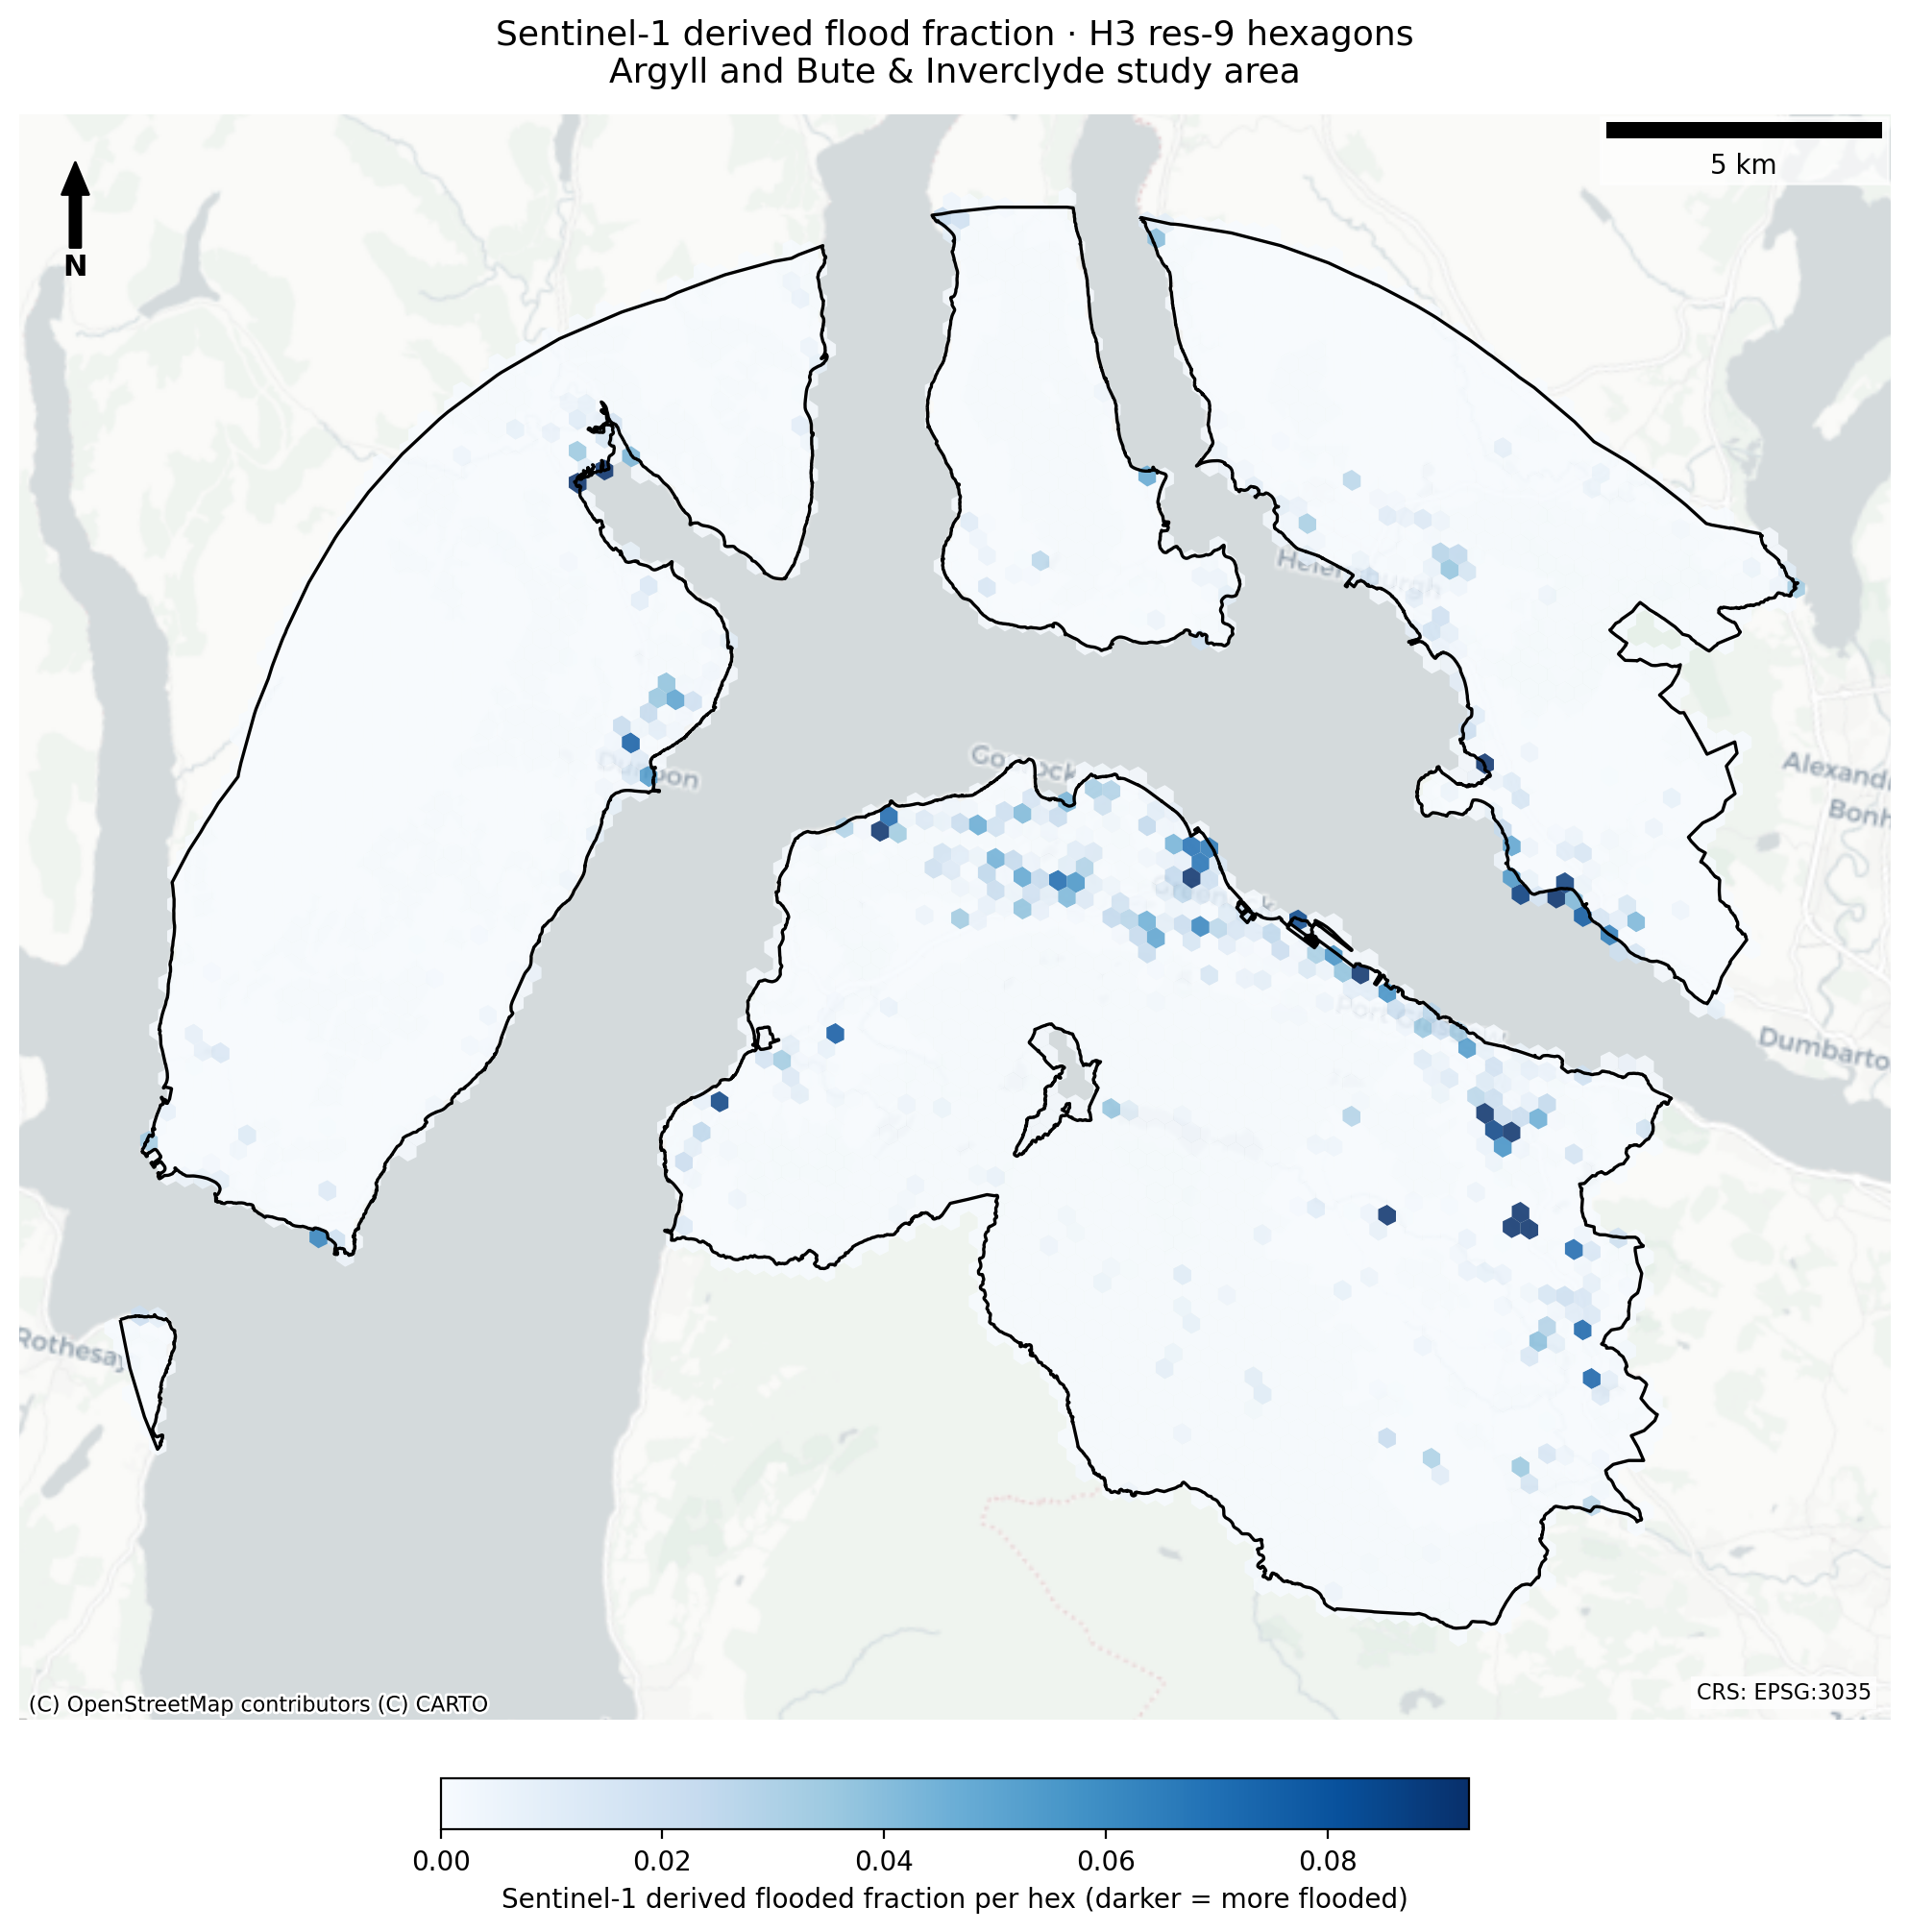

In [4]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx
from IPython.display import Image, display

TARGET_CRS = "EPSG:3035"
BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")
HEX_PATH = BASE / "hex_h3_res9_with_s1.gpkg"
AOI_PATH = BASE / "study_area_10Kmbuffer_dissolved.shp"
OUT_PNG = BASE / "s1_flood_frac_hex.png"

hexes = gpd.read_file(HEX_PATH)
if hexes.crs is None or hexes.crs.to_epsg() != 3035:
    hexes = hexes.to_crs(TARGET_CRS)

aoi = gpd.read_file(AOI_PATH).to_crs(TARGET_CRS)

ff = hexes.loc[hexes["s1_flood_frac"] > 0, "s1_flood_frac"]
vmax = float(ff.quantile(0.98)) if len(ff) else 1.0

fig, ax = plt.subplots(figsize=(11, 11), dpi=200)

hexes.plot(
    ax=ax,
    column="s1_flood_frac",
    cmap="Blues",
    edgecolor="none",
    alpha=0.85,
    zorder=2,
    legend=True,
    legend_kwds={
        "label": "Sentinel-1 derived flooded fraction per hex (darker = more flooded)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.03,
    },
    vmin=0,
    vmax=vmax,
)
aoi.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)

try:
    ctx.add_basemap(
        ax,
        crs=TARGET_CRS,
        source=ctx.providers.CartoDB.Positron,
        zoom="auto",
    )
    for artist in ax.get_images():
        artist.set_zorder(0)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "Sentinel-1 derived flood fraction · H3 res-9 hexagons\n"
    "Argyll and Bute & Inverclyde study area",
    fontsize=13,
    pad=12,
)
ax.add_artist(ScaleBar(1, units="m", location="upper right", box_alpha=0.7))
ax.annotate(
    "N",
    xy=(0.03, 0.97),
    xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center",
    fontsize=11,
    fontweight="bold",
)
ax.text(
    0.99,
    0.01,
    f"CRS: {TARGET_CRS}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    color="black",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200, bbox_inches="tight")
plt.close()
print(f"Saved: {OUT_PNG}")

display(Image(filename=str(OUT_PNG)))

# Zonal statistics : SEPA

Zonal statistics: SEPA eligible flood polygons -> H3 res-9 hexagon grid.

Produces per-hex 'sepa_flood_frac' = SEPA flooded area / land area within the hex,
restricted to the Sentinel-1 eligible domain.

In [6]:
from pathlib import Path
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union
from shapely.validation import make_valid

# Input
BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")

HEX_PATH = BASE / "hex_h3_res9.gpkg"
SEPA_PATH = BASE / "sepa_all_flood_epsg3035.shp"
ELIGIBILITY_GPKG = BASE / "cascade_outputs_slope30" / "sepa_eligibility.gpkg"

OUT_HEX = BASE / "hex_h3_res9_with_sepa_eligible.gpkg"

TARGET_CRS = "EPSG:3035"
ELIG_LAYER = "eligible_domain"

# Load and CRS check 
print(f"Loading hex grid: {HEX_PATH}")
hexes = gpd.read_file(HEX_PATH)
print(f"  {len(hexes):,} hexes, CRS {hexes.crs}")
if hexes.crs is None or hexes.crs.to_epsg() != 3035:
    print(f"  Reprojecting hex grid to {TARGET_CRS}")
    hexes = hexes.to_crs(TARGET_CRS)

print(f"Loading SEPA polygons: {SEPA_PATH}")
sepa = gpd.read_file(SEPA_PATH)
print(f"  {len(sepa):,} polygons, CRS {sepa.crs}")
if sepa.crs is None or sepa.crs.to_epsg() != 3035:
    print(f"  Reprojecting SEPA to {TARGET_CRS}")
    sepa = sepa.to_crs(TARGET_CRS)

print(f"Loading eligibility domain: {ELIGIBILITY_GPKG} | layer={ELIG_LAYER}")
elig = gpd.read_file(ELIGIBILITY_GPKG, layer=ELIG_LAYER)
print(f"  {len(elig):,} features, CRS {elig.crs}")
if elig.crs is None or elig.crs.to_epsg() != 3035:
    print(f"  Reprojecting eligibility domain to {TARGET_CRS}")
    elig = elig.to_crs(TARGET_CRS)

# Clean geomtries and clip SEPA to eligible domain 
sepa = sepa[sepa.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
sepa["geometry"] = sepa.geometry.apply(lambda g: make_valid(g) if not g.is_valid else g)

elig = elig[elig.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
elig["geometry"] = elig.geometry.apply(lambda g: make_valid(g) if not g.is_valid else g)

eligible_domain = unary_union(elig.geometry.values)

print("Clipping SEPA to eligible domain...")
sepa["geometry"] = sepa.geometry.intersection(eligible_domain)
sepa = sepa[~sepa.geometry.is_empty].copy()

# Dissolve after clipping so overlapping SEPA polygons are not double-counted.
sepa_union = sepa.dissolve().reset_index(drop=True)
print(f"  Eligible SEPA dissolved area: {sepa_union.geometry.area.sum() / 1e6:.2f} km2")

# Per-Hex flooded area via polygone intersection 
print("Intersecting hexes with eligible SEPA surface...")
inter = gpd.overlay(
    hexes[["h3_id", "geometry"]],
    sepa_union[["geometry"]],
    how="intersection",
    keep_geom_type=True,
)
inter["piece_area_m2"] = inter.geometry.area

sepa_area = (
    inter.groupby("h3_id")["piece_area_m2"]
    .sum()
    .rename("sepa_flood_area_m2")
)

# Derive fractions 
hexes = hexes.merge(sepa_area, on="h3_id", how="left")
hexes["sepa_flood_area_m2"] = hexes["sepa_flood_area_m2"].fillna(0.0)

hexes["sepa_flood_frac"] = np.where(
    hexes["land_area_m2"] > 0,
    hexes["sepa_flood_area_m2"] / hexes["land_area_m2"],
    0.0,
)
hexes["sepa_flood_frac"] = hexes["sepa_flood_frac"].clip(upper=1.0)

hexes["sepa_flood_frac_full"] = hexes["sepa_flood_area_m2"] / hexes["hex_area_m2"]

# Audit 
print("\n=== SEPA ELIGIBLE ZONAL AUDIT ===")
print(f"Hexes total:                    {len(hexes):,}")
print(f"Hexes with any SEPA flood:      {(hexes['sepa_flood_area_m2'] > 0).sum():,} "
      f"({100 * (hexes['sepa_flood_area_m2'] > 0).mean():.2f}%)")
print(f"Total SEPA eligible area (km^2): {hexes['sepa_flood_area_m2'].sum() / 1e6:.4f}")

print("\nsepa_flood_frac distribution (non-zero hexes only):")
nz = hexes[hexes["sepa_flood_frac"] > 0]["sepa_flood_frac"]
if len(nz):
    print(f"  n:      {len(nz):,}")
    print(f"  mean:   {nz.mean():.4f}")
    print(f"  median: {nz.median():.4f}")
    print(f"  p95:    {nz.quantile(0.95):.4f}")
    print(f"  max:    {nz.max():.4f}")

print(f"\nSanity: per-hex SEPA eligible area vs dissolved eligible total.")
print(f"  Per-hex sum:   {hexes['sepa_flood_area_m2'].sum() / 1e6:.2f} km2")
print(f"  Dissolved:     {sepa_union.geometry.area.sum() / 1e6:.2f} km2")

# Save
hexes.to_file(OUT_HEX, driver="GPKG")
print(f"\nSaved: {OUT_HEX}")

Loading hex grid: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/hex_h3_res9.gpkg
  4,201 hexes, CRS EPSG:3035
Loading SEPA polygons: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/sepa_all_flood_epsg3035.shp
  26,876 polygons, CRS EPSG:3035
Loading eligibility domain: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/cascade_outputs_slope30/sepa_eligibility.gpkg | layer=eligible_domain
  1 features, CRS EPSG:3035
Clipping SEPA to eligible domain...
  Eligible SEPA dissolved area: 12.46 km2
Intersecting hexes with eligible SEPA surface...

=== SEPA ELIGIBLE ZONAL AUDIT ===
Hexes total:                    4,201
Hexes with any SEPA flood:      3,314 (78.89%)
Total SEPA eligible area (km^2): 12.4335

sepa_flood_frac distribution (non-zero hexes only):
  n:      3,314
  mean:   0.0407
  median: 0.0153
  p95:    0.1641
  max:    0.9945

Sanity: per-hex SEPA eligible area vs dissolved eligible total.
  Per-hex sum:   12.43 km2
  Dissolved:     12.46 km2

Saved: /Us

Saved: sepa_flood_frac_hex.png


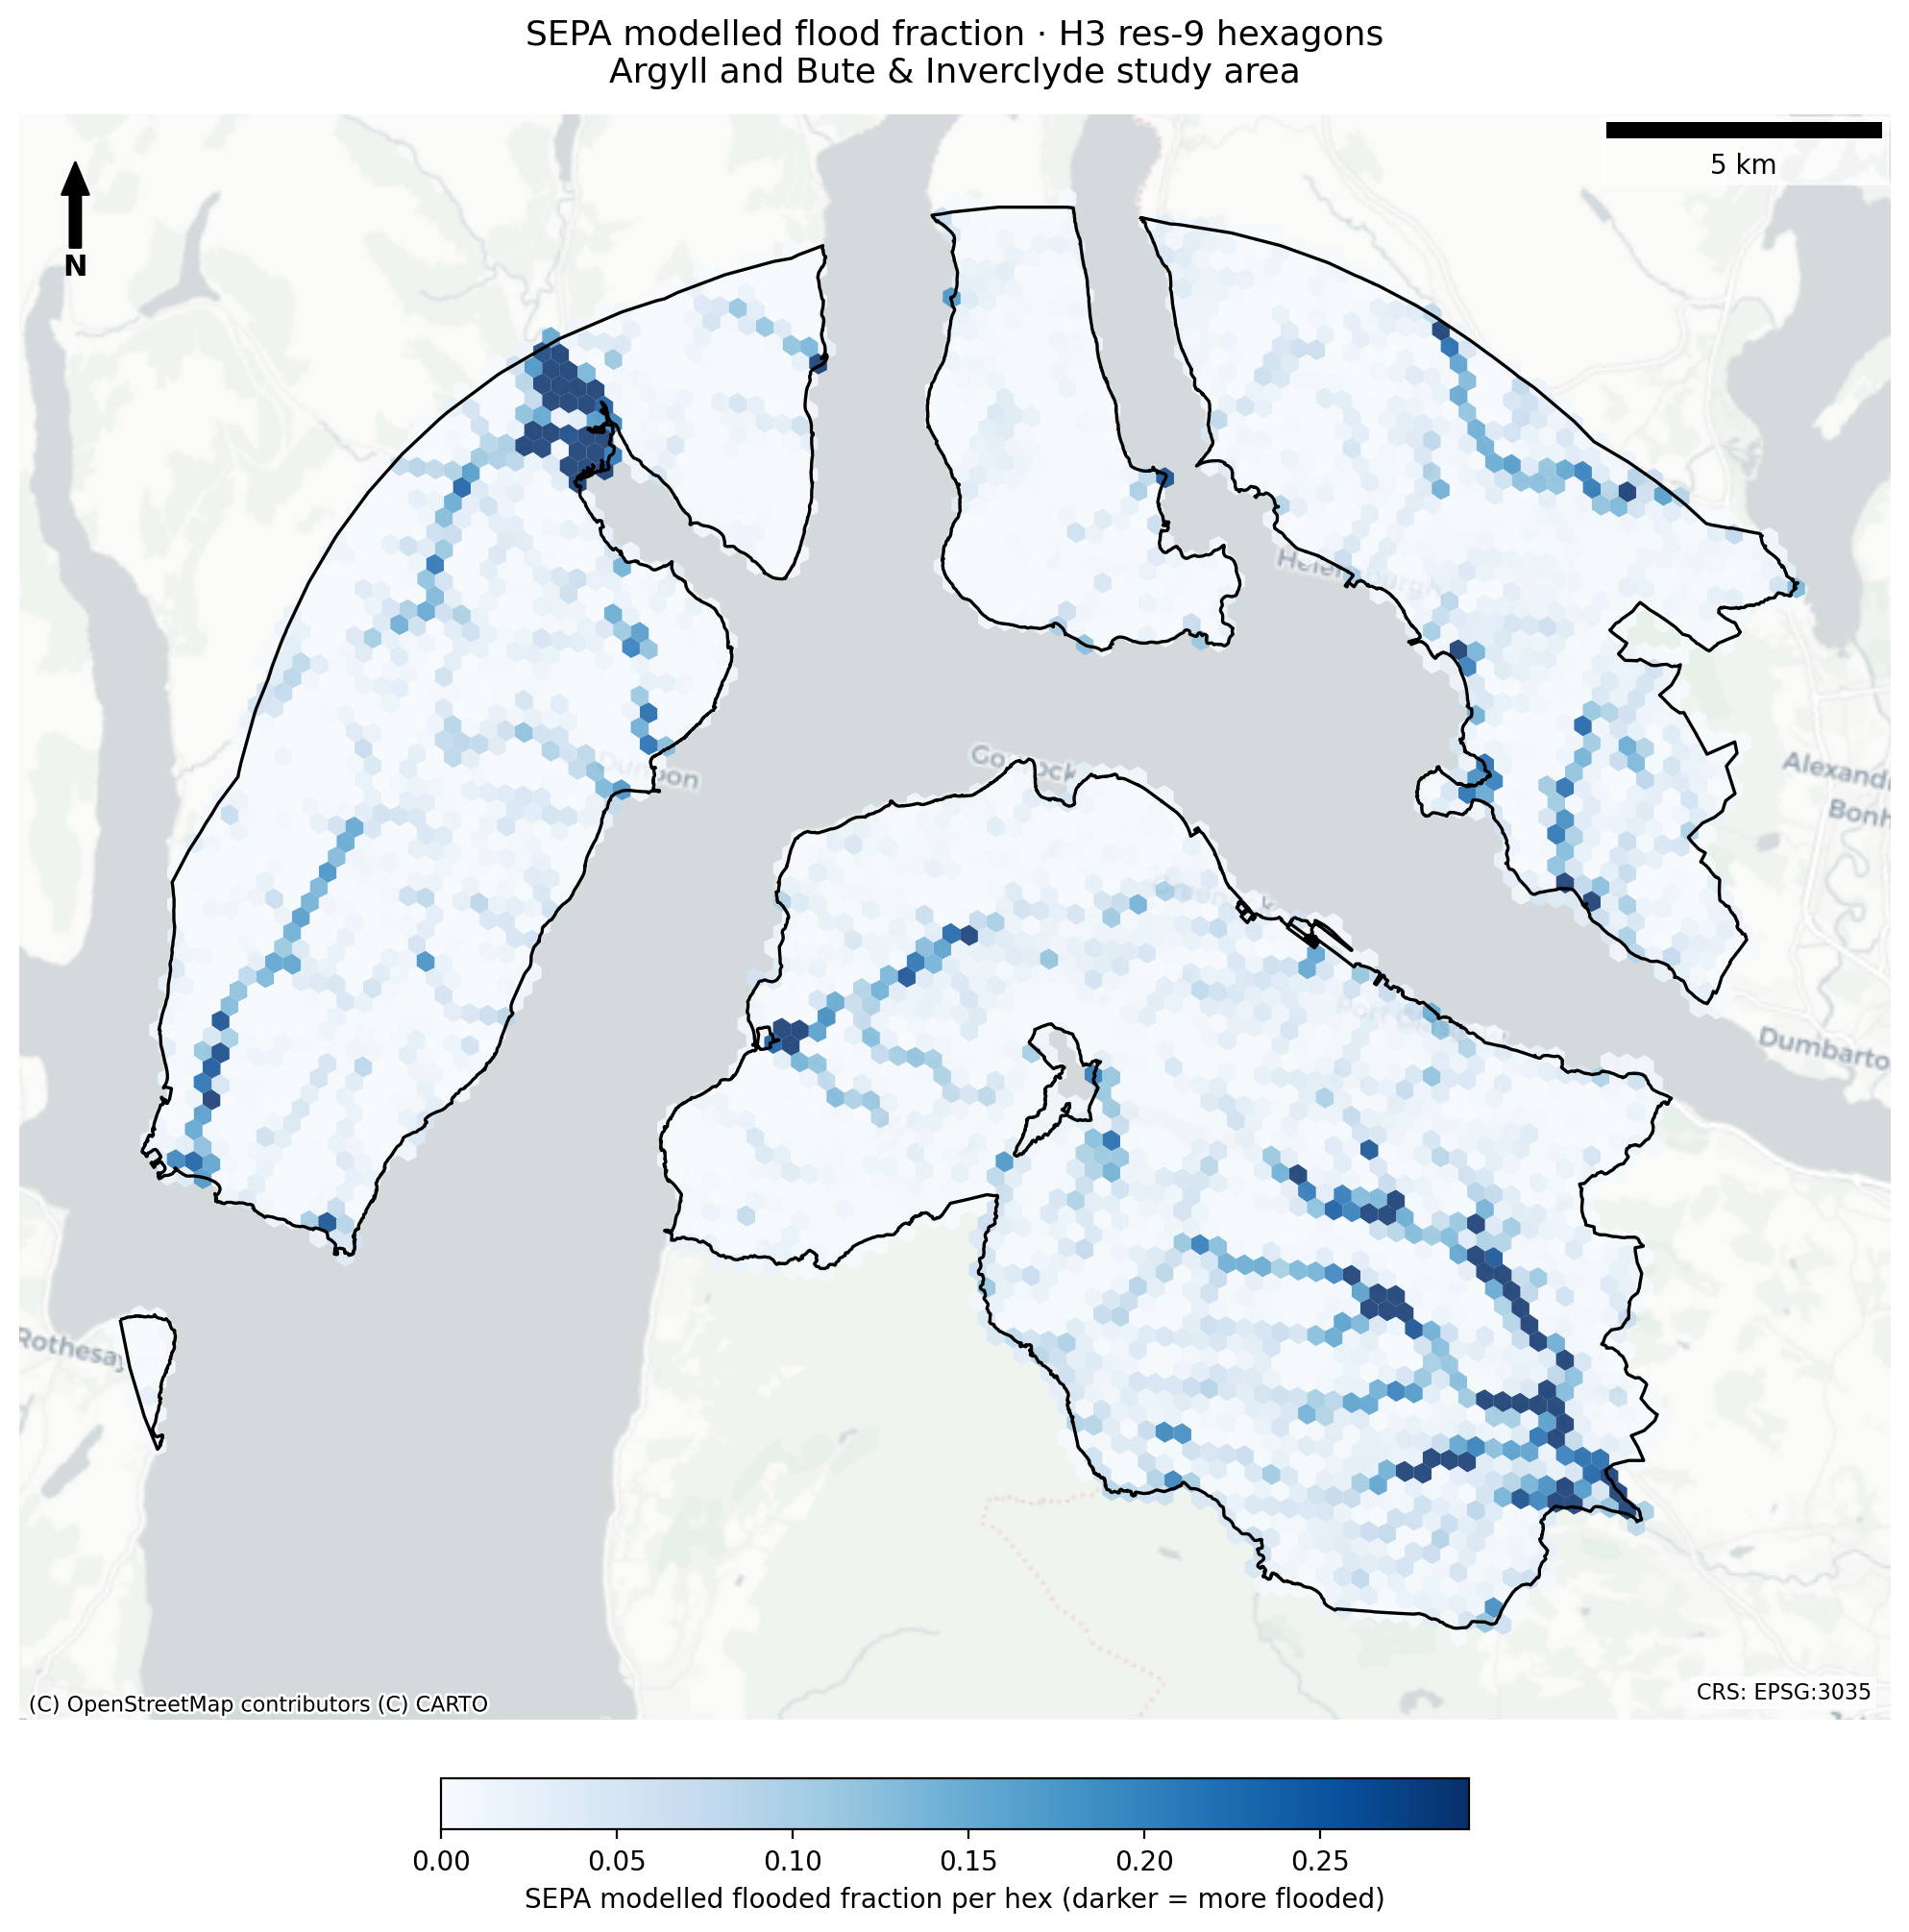

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx

TARGET_CRS = "EPSG:3035"

# Load
hexes = gpd.read_file("hex_h3_res9_with_sepa_eligible.gpkg")
if hexes.crs is None or hexes.crs.to_epsg() != 3035:
    hexes = hexes.to_crs(TARGET_CRS)
aoi = gpd.read_file("study_area_10Kmbuffer_dissolved.shp").to_crs(TARGET_CRS)

# Upper stretch from the data so a few high hexes don't wash the map out.
ff = hexes.loc[hexes["sepa_flood_frac"] > 0, "sepa_flood_frac"]
vmax = float(ff.quantile(0.98)) if len(ff) else 1.0

fig, ax = plt.subplots(figsize=(11, 11), dpi=200)

hexes.plot(
    ax=ax,
    column="sepa_flood_frac",
    cmap="Blues",          # sequential; dark = more flooded
    edgecolor="none",
    alpha=0.85,
    zorder=2,
    legend=True,
    legend_kwds={
        "label": "SEPA modelled flooded fraction per hex (darker = more flooded)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.03,
    },
    vmin=0,
    vmax=vmax,
)
aoi.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)

try:
    ctx.add_basemap(ax, crs=TARGET_CRS,
                    source=ctx.providers.CartoDB.Positron, zoom="auto")
    for artist in ax.get_images():
        artist.set_zorder(0)
except Exception as e:
    print(f"Basemap unavailable ({e}); plotting without it.")
    ax.set_facecolor("#f0f0f0")

ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    "SEPA modelled flood fraction · H3 res-9 hexagons\n"
    "Argyll and Bute & Inverclyde study area",
    fontsize=13, pad=12,
)
ax.add_artist(ScaleBar(1, units="m", location="upper right", box_alpha=0.7))
ax.annotate(
    "N", xy=(0.03, 0.97), xytext=(0.03, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=4, headwidth=10),
    ha="center", fontsize=11, fontweight="bold",
)
ax.text(
    0.99, 0.01, f"CRS: {TARGET_CRS}",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=8, color="black",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
)

plt.tight_layout()
plt.savefig("sepa_flood_frac_hex.png", dpi=200, bbox_inches="tight")
plt.close()
print("Saved: sepa_flood_frac_hex.png")

Image("sepa_flood_frac_hex.png")